## import library

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

## load data

In [13]:
df = pd.read_csv('dataset/dataset_paprika_ec.csv')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df.head()

,Timestamp,Suhu_Udara,Kelembapan_Udara,Kelembapan_Tanah,EC_Tangki,N,P,K,Status_Pompa,Fase,target_ec
0,2025-12-01 00:00:00,25.41,83.49,58.00,1.6,162.43,62.17,237.73,0,0,1.7
1,2025-12-01 01:00:00,24.47,85.00,57.86,1.6,163.18,60.81,238.90,0,0,1.7
2,2025-12-01 02:00:00,24.91,81.16,57.58,1.6,159.42,60.18,233.82,0,0,1.7
3,2025-12-01 03:00:00,25.53,83.80,57.81,1.6,156.31,60.91,231.24,0,0,1.7
4,2025-12-01 04:00:00,23.89,82.60,57.16,1.6,158.13,63.27,231.03,0,0,1.7


## Feature Engineering (Ekstrak Umur Tanaman)

In [14]:
# Di dataset asli cuma ada Timestamp. Kita perlu bikin kolom Umur_Tanaman (hari).
# Asumsi kita set tanggal tanam secara statis berdasarkan data historis.
# Berdasarkan contoh UI kamu (umur 46 hari), misal kita set tanggal tanam 46 hari sebelum log pertama.
tanggal_tanam = pd.to_datetime('2025-10-16') 

# Hitung selisih hari
df['Umur_Tanaman'] = (df['Timestamp'] - tanggal_tanam).dt.days

# Cek hasilnya
print(df[['Timestamp', 'Umur_Tanaman']].head())

            Timestamp  Umur_Tanaman
0 2025-12-01 00:00:00            46
1 2025-12-01 01:00:00            46
2 2025-12-01 02:00:00            46
3 2025-12-01 03:00:00            46
4 2025-12-01 04:00:00            46


## Seleksi Fitur dan Target

In [15]:
# Tentukan Features (X) berdasarkan sensor lingkungan & input user
features = ['Suhu_Udara', 'Kelembapan_Udara', 'Kelembapan_Tanah', 'Umur_Tanaman']

# Tentukan Target (y)
target = 'target_ec'

X = df[features]
y = df[target]

# Tampilkan info matriks
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

Shape X: (4368, 4)
Shape y: (4368,)


## Split Data Training & Testing

In [16]:
# Kita pecah 80% data untuk training, 20% untuk testing/evaluasi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 3494
Jumlah data uji: 874


## Training Model Random Forest

In [17]:
# Inisialisasi model
# n_estimators: jumlah decision tree. max_depth: kedalaman maksimal pohon biar nggak overfitting.
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Mulai training
rf_model.fit(X_train, y_train)

print("Training selesai!")

Training selesai!


## Evaluasi Model

Mean Absolute Error (MAE): 0.0009
Root Mean Squared Error (RMSE): 0.0105
R-squared (R2): 0.9969


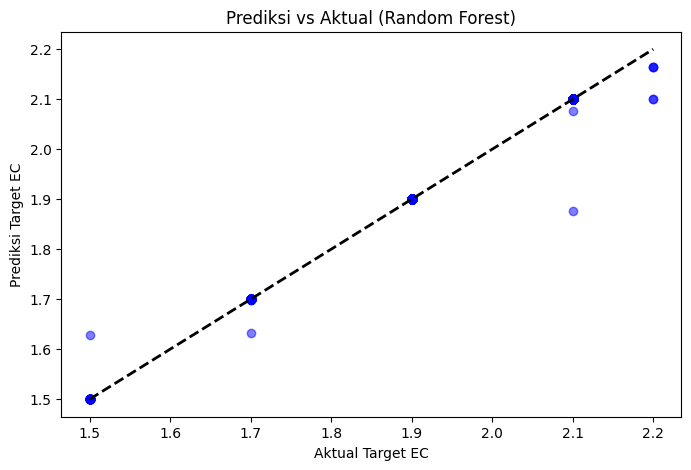

In [18]:
# Prediksi data testing
y_pred = rf_model.predict(X_test)

# Hitung metrik error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Aktual Target EC')
plt.ylabel('Prediksi Target EC')
plt.title('Prediksi vs Aktual (Random Forest)')
plt.show()

## Simulasi Prediksi

In [19]:
# Suhu: 31°C, Kelembapan Udara: 80% (asumsi), Kelembapan Tanah: 65% (asumsi), Umur: 46 hari
data_dummy = pd.DataFrame([[31.0, 80.0, 65.0, 46]], columns=features)

prediksi_ec = rf_model.predict(data_dummy)
print(f"Rekomendasi Target EC untuk kondisi saat ini: {prediksi_ec[0]:.2f} mS/cm")

Rekomendasi Target EC untuk kondisi saat ini: 1.50 mS/cm


## Export Model

In [20]:
# Export model ke format .pkl 
joblib.dump(rf_model, 'model/model_rf_paprika.pkl')
print("Model berhasil disimpan sebagai 'model_rf_paprika.pkl'")

Model berhasil disimpan sebagai 'model_rf_paprika.pkl'
